In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
df = pd.read_json("BFCL_v4_multi_turn_base.json", lines=True)
tool_calls_df = pd.read_json("possible_answer/BFCL_v4_multi_turn_base.json", lines=True)

In [3]:
df

,id,question,initial_config,path,involved_classes,excluded_function
0,multi_turn_base_0,"[[{'role': 'user', 'content': 'Move 'final_rep...",{'GorillaFileSystem': {'root': {'workspace': {...,"[GorillaFileSystem.find, GorillaFileSystem.mv,...","[TwitterAPI, GorillaFileSystem]",[cp]
1,multi_turn_base_1,"[[{'role': 'user', 'content': 'I am alex. Chec...",{'GorillaFileSystem': {'root': {'alex': {'type...,"[GorillaFileSystem.ls, GorillaFileSystem.find,...",[GorillaFileSystem],[cp]
2,multi_turn_base_2,"[[{'role': 'user', 'content': 'Go into documen...",{'GorillaFileSystem': {'root': {'simona': {'ty...,"[GorillaFileSystem.touch, GorillaFileSystem.ec...","[TicketAPI, GorillaFileSystem]",[rm]
3,multi_turn_base_3,"[[{'role': 'user', 'content': 'As part of my l...",{'GorillaFileSystem': {'root': {'alex': {'type...,"[GorillaFileSystem.cd, GorillaFileSystem.find,...",[GorillaFileSystem],[mv]
4,multi_turn_base_4,"[[{'role': 'user', 'content': 'Could you kindl...",{'GorillaFileSystem': {'root': {'tmp': {'type'...,"[GorillaFileSystem.cd, GorillaFileSystem.echo,...","[TwitterAPI, GorillaFileSystem]",NaN
...,...,...,...,...,...,...
195,multi_turn_base_195,"[[{'role': 'user', 'content': 'I really really...",{'TravelAPI': {'credit_card_list': {'1_3456': ...,"[TravelAPI.get_nearest_airport_by_city, Travel...","[TwitterAPI, TravelAPI]",NaN
196,multi_turn_base_196,"[[{'role': 'user', 'content': 'Gearing up for ...",{'TravelAPI': {'credit_card_list': {'primary_8...,"[TravelAPI.compute_exchange_rate, TravelAPI.se...","[TicketAPI, TravelAPI]",NaN
197,multi_turn_base_197,"[[{'role': 'user', 'content': 'I have a fabulo...","{'TravelAPI': {'credit_card_list': {}, 'bookin...","[TravelAPI.register_credit_card, TravelAPI.pur...","[MessageAPI, TravelAPI]",NaN
198,multi_turn_base_198,"[[{'role': 'user', 'content': 'OMG, a first-cl...",{'TravelAPI': {'credit_card_list': {'6789': {'...,"[TravelAPI.get_flight_cost, TravelAPI.book_fli...","[TwitterAPI, TravelAPI]",NaN


In [4]:
tool_calls_df

,id,ground_truth
0,multi_turn_base_0,"[[cd(folder='document'), mkdir(dir_name='temp'..."
1,multi_turn_base_1,"[[ls(a=True)], [cd(folder='workspace'), mv(sou..."
2,multi_turn_base_2,"[[cd(folder='documents'), touch(file_name='Tea..."
3,multi_turn_base_3,"[[find(path='.',name='test')], [cd(folder='pro..."
4,multi_turn_base_4,"[[ls(a=True)], [sort(file_name='report.txt')],..."
...,...,...
195,multi_turn_base_195,"[[get_flight_cost(travel_from='RMS',travel_to=..."
196,multi_turn_base_196,"[[compute_exchange_rate(base_currency='RMB', t..."
197,multi_turn_base_197,[[register_credit_card(access_token='abc123xyz...
198,multi_turn_base_198,"[[get_flight_cost(travel_from='SFO', travel_to..."


In [5]:
# These are taken from https://gorilla.cs.berkeley.edu/blogs/13_bfcl_v3_multi_turn.html#composition
PRIMARY_APIS = ["GorillaFileSystem", "TradingBot", "TravelAPI", "VehicleControlAPI"]
SECONDARY_APIS = ["TicketAPI", "TwitterAPI", "MessageAPI", "MathAPI"]

In [6]:
indiv_classes_cnt = Counter()
for classes in df["involved_classes"]:
    curr_cnt = Counter(classes)
    indiv_classes_cnt.update(curr_cnt)

In [7]:
indiv_classes_cnt

Counter({'GorillaFileSystem': 50,
         'VehicleControlAPI': 50,
         'TradingBot': 50,
         'TravelAPI': 50,
         'MessageAPI': 40,
         'TwitterAPI': 39,
         'TicketAPI': 31,
         'MathAPI': 25})

In [8]:
combo_classes_list = []
for classes in df["involved_classes"]:
    classes_str = ",".join(sorted(classes))
    combo_classes_list.append(classes_str)
combo_classes_cnt = Counter(combo_classes_list)

In [9]:
combo_classes_cnt

Counter({'TradingBot': 20,
         'VehicleControlAPI': 19,
         'TicketAPI,TravelAPI': 15,
         'TwitterAPI,VehicleControlAPI': 14,
         'GorillaFileSystem': 13,
         'MessageAPI,TradingBot': 13,
         'TravelAPI': 13,
         'GorillaFileSystem,TwitterAPI': 12,
         'GorillaFileSystem,MathAPI': 12,
         'TravelAPI,TwitterAPI': 10,
         'MessageAPI,TravelAPI': 10,
         'MessageAPI,VehicleControlAPI': 9,
         'TicketAPI,TradingBot': 9,
         'GorillaFileSystem,MessageAPI': 8,
         'MathAPI,VehicleControlAPI': 6,
         'GorillaFileSystem,TicketAPI': 5,
         'MathAPI,TradingBot': 5,
         'TradingBot,TwitterAPI': 3,
         'TicketAPI,VehicleControlAPI': 2,
         'MathAPI,TravelAPI': 2})

In [10]:
tool_cnt = Counter()
for tools in df["path"]:
    curr_cnt = Counter(tools)
    tool_cnt.update(curr_cnt)

In [11]:
tool_cnt

Counter({'VehicleControlAPI.startEngine': 46,
         'TradingBot.get_stock_info': 42,
         'TravelAPI.book_flight': 42,
         'TwitterAPI.post_tweet': 39,
         'MessageAPI.send_message': 38,
         'VehicleControlAPI.fillFuelTank': 35,
         'TradingBot.get_order_details': 33,
         'TradingBot.place_order': 29,
         'TravelAPI.get_flight_cost': 28,
         'GorillaFileSystem.mv': 27,
         'TravelAPI.retrieve_invoice': 27,
         'TradingBot.get_symbol_by_name': 25,
         'TravelAPI.cancel_booking': 25,
         'GorillaFileSystem.sort': 24,
         'VehicleControlAPI.check_tire_pressure': 24,
         'GorillaFileSystem.cp': 23,
         'GorillaFileSystem.cat': 22,
         'VehicleControlAPI.get_zipcode_based_on_city': 22,
         'TradingBot.cancel_order': 22,
         'TicketAPI.create_ticket': 21,
         'VehicleControlAPI.estimate_distance': 21,
         'GorillaFileSystem.find': 20,
         'GorillaFileSystem.grep': 19,
         'MessageA

In [12]:
primary_tool_cnt = Counter()
for k, v in tool_cnt.items():
    api = k.split(".")[0]
    if api in PRIMARY_APIS: 
        primary_tool_cnt.update({f"{k}": v})

In [13]:
primary_tool_cnt 

Counter({'VehicleControlAPI.startEngine': 46,
         'TradingBot.get_stock_info': 42,
         'TravelAPI.book_flight': 42,
         'VehicleControlAPI.fillFuelTank': 35,
         'TradingBot.get_order_details': 33,
         'TradingBot.place_order': 29,
         'TravelAPI.get_flight_cost': 28,
         'GorillaFileSystem.mv': 27,
         'TravelAPI.retrieve_invoice': 27,
         'TradingBot.get_symbol_by_name': 25,
         'TravelAPI.cancel_booking': 25,
         'GorillaFileSystem.sort': 24,
         'VehicleControlAPI.check_tire_pressure': 24,
         'GorillaFileSystem.cp': 23,
         'GorillaFileSystem.cat': 22,
         'VehicleControlAPI.get_zipcode_based_on_city': 22,
         'TradingBot.cancel_order': 22,
         'VehicleControlAPI.estimate_distance': 21,
         'GorillaFileSystem.find': 20,
         'GorillaFileSystem.grep': 19,
         'TradingBot.get_watchlist': 19,
         'TravelAPI.get_nearest_airport_by_city': 19,
         'GorillaFileSystem.cd': 18,
    

In [14]:
tool_cnt_from_possible_answer = Counter()
for turn_tools in tool_calls_df["ground_truth"]:
    for step_tools in turn_tools:
        tools = [tc.split("(")[0] for tc in step_tools]
        curr_cnt = Counter(tools)
        tool_cnt_from_possible_answer.update(curr_cnt)

In [15]:
tool_cnt_from_possible_answer

Counter({'cd': 51,
         'pressBrakePedal': 44,
         'startEngine': 44,
         'get_stock_info': 43,
         'lockDoors': 42,
         'book_flight': 41,
         'get_zipcode_based_on_city': 38,
         'get_flight_cost': 36,
         'post_tweet': 34,
         'fillFuelTank': 32,
         'get_order_details': 32,
         'place_order': 29,
         'send_message': 28,
         'retrieve_invoice': 25,
         'check_tire_pressure': 24,
         'touch': 22,
         'echo': 22,
         'estimate_distance': 20,
         'get_watchlist': 20,
         'cat': 19,
         'cancel_order': 19,
         'add_to_watchlist': 19,
         'cancel_booking': 19,
         'create_ticket': 18,
         'view_messages_sent': 17,
         'set_budget_limit': 17,
         'wc': 16,
         'mv': 15,
         'cp': 15,
         'contact_customer_support': 15,
         'authenticate_twitter': 14,
         'get_account_info': 14,
         'find_nearest_tire_shop': 13,
         'ls': 12,
  

<Axes: ylabel='Frequency'>

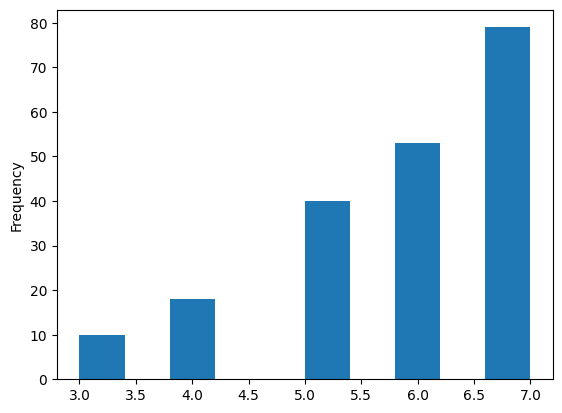

In [16]:
df["n_path"] = df["path"].apply(lambda x: len(x))
df["n_path"].plot(kind="hist")

<Axes: ylabel='Frequency'>

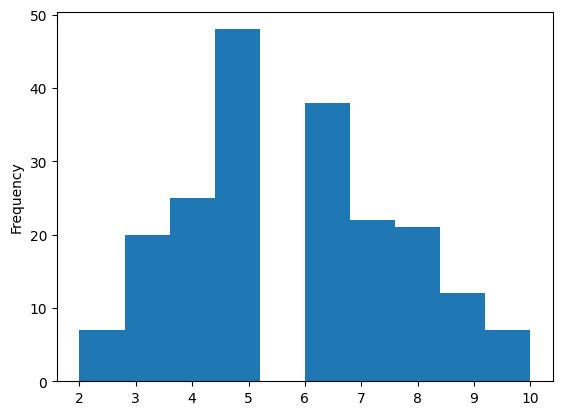

In [17]:
def get_flatten_tc_list(tc): 
    tc_list = []
    for turn_tc in tc:
        for step_tc in turn_tc:
            tc_list.append(step_tc)
    return tc_list

tool_calls_df["n_tool_calls"] = tool_calls_df["ground_truth"].apply(lambda x: len(get_flatten_tc_list(x)))
tool_calls_df["n_tool_calls"].plot(kind="hist")

<Axes: ylabel='Frequency'>

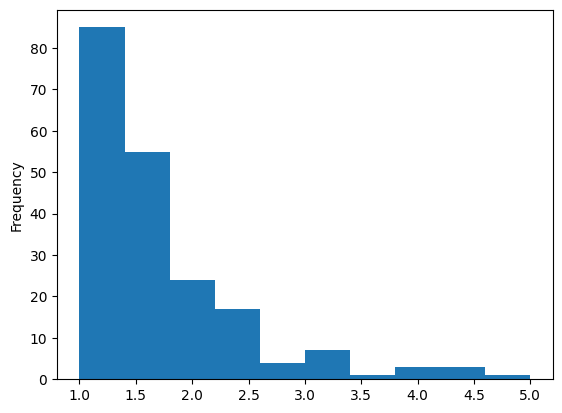

In [18]:
def get_avg_tc_per_turn(tc): 
    tc_lens = [len(x) for x in tc]
    tc_lens_sum = sum(tc_lens)
    return tc_lens_sum / len(tc_lens)

tool_calls_df["avg_tool_calls_per_turn"] = tool_calls_df["ground_truth"].apply(get_avg_tc_per_turn)
tool_calls_df["avg_tool_calls_per_turn"].plot(kind="hist")

<Axes: ylabel='Frequency'>

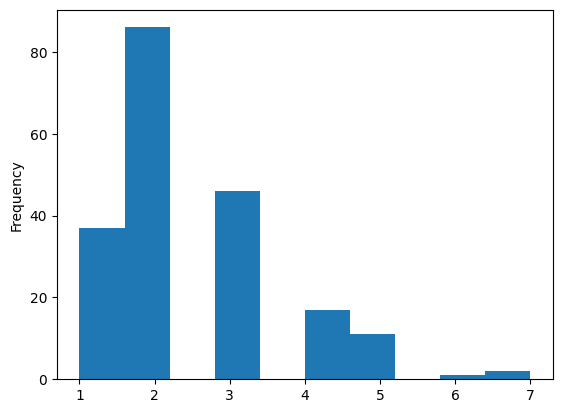

In [19]:
def get_max_tc_per_turn(tc): 
    tc_lens = [len(x) for x in tc]
    return max(tc_lens)

tool_calls_df["max_tool_calls_per_turn"] = tool_calls_df["ground_truth"].apply(get_max_tc_per_turn)
tool_calls_df["max_tool_calls_per_turn"].plot(kind="hist")

<Axes: ylabel='Frequency'>

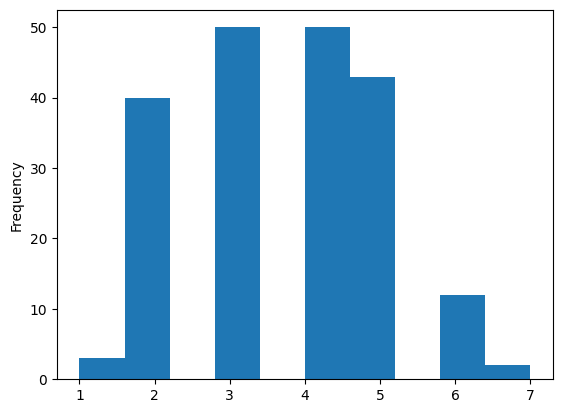

In [20]:
df["n_questions"] = df["question"].apply(lambda x: len(x))
df["n_questions"].plot(kind="hist")

In [21]:
def has_excl_func(excl_func):
    if not pd.isna(excl_func):
        return len(excl_func) > 0
    return False
    
df["has_excl_func"] = df["excluded_function"].apply(has_excl_func)
df["has_excl_func"].value_counts()

has_excl_func
False    182
True      18
Name: count, dtype: int64

In [22]:
risky_funcs = [
    "GorillaFileSystem.rm",
    "GorillaFileSystem.rmdir",
    "TradingBot.cancel_order",
    "TradingBot.withdraw_funds",
    "TradingBot.remove_stock_from_watchlist",
    "TravelBooking.cancel_booking"
]

def get_has_risky_func(funcs):
    for f in funcs:
        if f in risky_funcs:
            return True
    return False
    
df["has_risky_func"] = df["path"].apply(get_has_risky_func)
df["has_risky_func"].value_counts()

has_risky_func
False    170
True      30
Name: count, dtype: int64

### Dimensions
| # | Dimension | Possible Values | Source |
|---|---|---|---|                                                                                                                        
| 1 | Primary API | GorillaFileSystem, TradingBot, TravelAPI, VehicleControlAPI | `involved_classes` |
| 2 | Secondary API | TicketAPI, TwitterAPI, MessageAPI, MathAPI, None | `involved_classes` |
| 3 | Conversation Length | short (<=2 questions), medium (3-5 questions), long (>=6 questions) | `question` |
| 4 | Number of Tool Calls | low (<=4 tc), medium (5-7 tc), high (>=8 tc) | `possible_answer.ground_truth` |
| 5 | Max Tool Calls Per Turn | low (<=2 max tc), medium (3-5 max tc), high (>=6 max tc) | `possible_answer.ground_truth` |
| 6 | Has Excluded Function | true, false | `excluded_function` |
| 7 | Has Risky State Update | true, false (e.g. deleting a file) | `path` |

#### Notes
Possible classes:
1. Primary API: GorillaFileSystem, TradingBot, TravelAPI, VehicleControlAPI
2. Secondary API: TicketAPI, TwitterAPI, MessageAPI, MathAPI, or None
3. Conversation length: short (<=2 questions), medium (3-5 questions), long (>=6 questions)
4. Number of Tool Calls (from possible_answer data that has the tool calls): small (<=4), medium (5-7), large (>=8)
5. Max Number of Tool Calls Per Turn (from possible_answer data that has the tool calls): low (<=2), medium (3-5), high (>=6)
6. Has Excluded Func: true, false
7. Has Risky State Update APIs (e.g. deleting a file): true, false
8. User Persona?: beginner, intermediate, advanced (needs an LLM, maybe avoid for now)